Generating realistic LFP data...


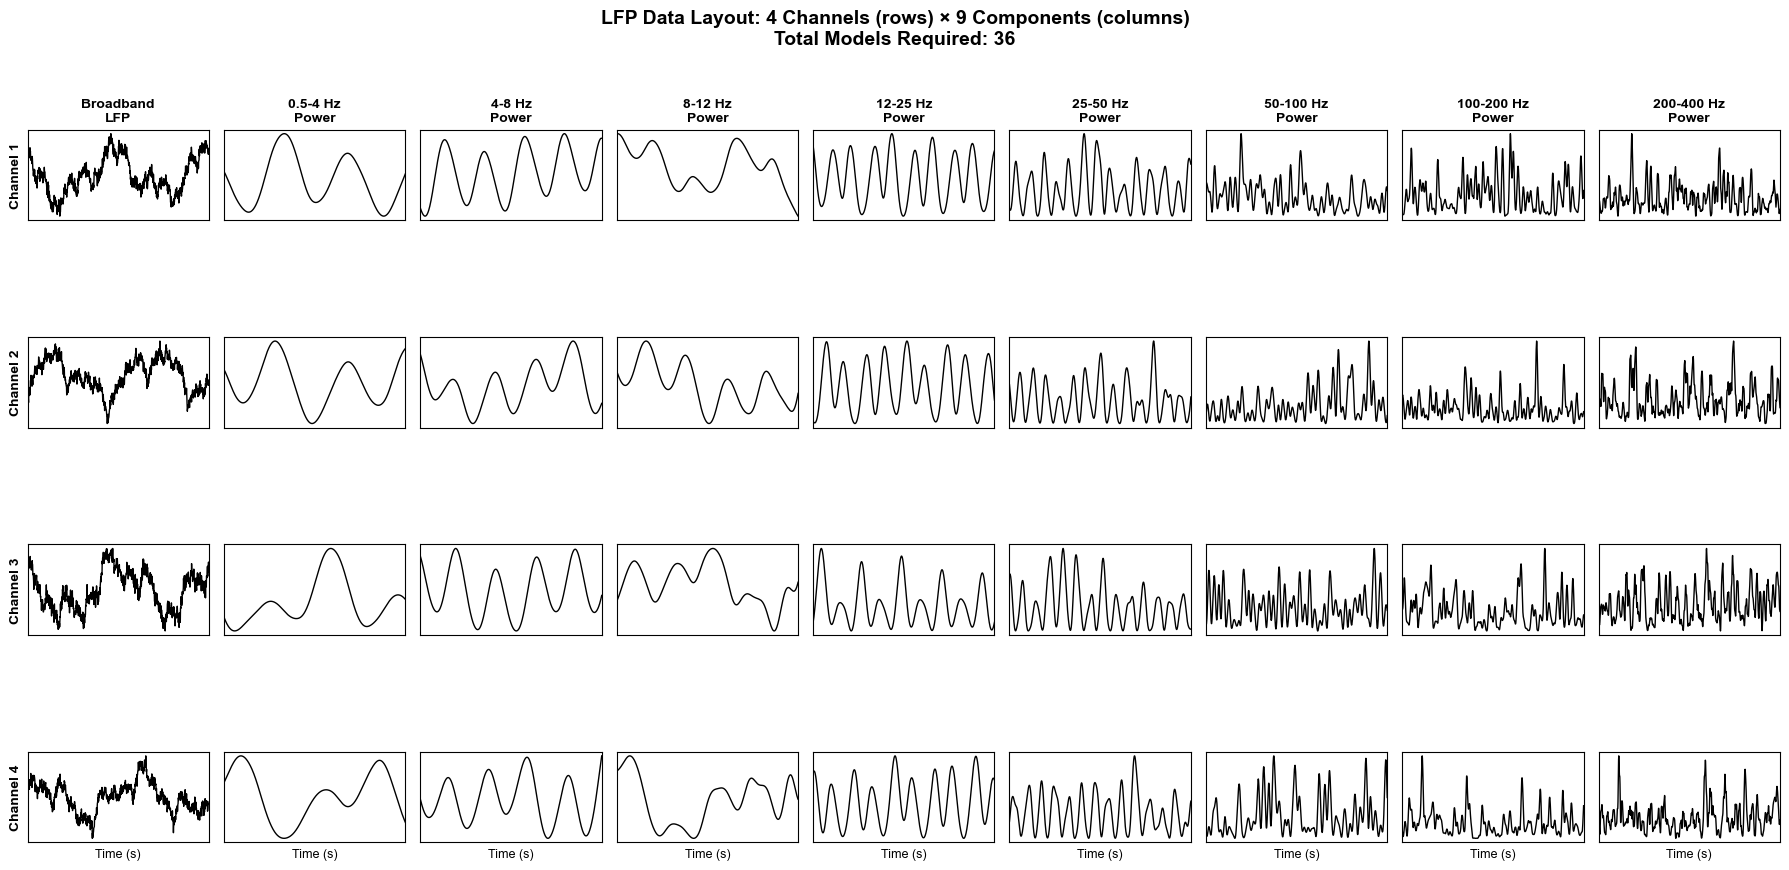


Generated 36 model targets from realistic LFP data
Layout: Rows = Channels, Columns = Frequency Components
Power data is z-scored (mean=0, std=1)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import hilbert
from pathlib import Path

# Parameters
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
n_channels = 4
n_bands = len(bands)
n_models = n_channels * (n_bands + 1)

# Simulation parameters
fs = 1000
duration = 2
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

plt.rcParams.update({
    'pdf.fonttype': 42,  # Output Type 42 (TrueType) fonts instead of Type 3
    'ps.fonttype': 42,   # Also for PostScript
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 10,
    'text.usetex': False  # Don't use LaTeX rendering
})

figures_folder = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures'


def generate_simple_realistic_lfp(t, fs, channel=0):
    """Generate simple but realistic LFP signal"""
    N = len(t)
    
    # Start with white noise
    signal_lfp = np.random.randn(N) * 10
    
    # Add oscillations at different frequencies with 1/f amplitude scaling
    frequencies = [2, 5, 10, 15, 25, 40, 60, 100, 150]  # Key frequencies
    
    for freq in frequencies:
        # Amplitude decreases with frequency (1/f-like)
        amplitude = 100 / (freq**0.7)  # Scale amplitude
        phase = np.random.uniform(0, 2*np.pi)  # Random phase
        oscillation = amplitude * np.sin(2 * np.pi * freq * t + phase)
        signal_lfp += oscillation
    
    # Add some slow drifts
    slow_drift = 50 * np.sin(2 * np.pi * 0.1 * t) + 20 * np.sin(2 * np.pi * 0.05 * t)
    signal_lfp += slow_drift
    
    # Add channel-specific offset
    signal_lfp += channel * 25
    
    return signal_lfp

def extract_band_power(signal_data, fs, low_freq, high_freq):
    """Extract instantaneous power in frequency band"""
    nyquist = fs / 2
    if high_freq >= nyquist:
        high_freq = nyquist * 0.95
    
    # Bandpass filter
    sos = signal.butter(4, [low_freq, high_freq], btype='band', fs=fs, output='sos')
    filtered = signal.sosfilt(sos, signal_data)
    
    # Instantaneous power via Hilbert transform
    analytic = hilbert(filtered)
    power = np.abs(analytic) ** 2
    
    # Light smoothing (10ms window)
    smooth_samples = int(fs * 0.01)
    if smooth_samples > 1:
        kernel = np.ones(smooth_samples) / smooth_samples
        power = np.convolve(power, kernel, mode='same')
    
    return power

def zscore(data):
    """Z-score normalization"""
    return (data - np.mean(data)) / np.std(data)

# Generate data
np.random.seed(42)
simulated_data = np.zeros((len(t), n_channels, n_bands + 1))

print("Generating realistic LFP data...")

for chan in range(n_channels):
    np.random.seed(42 + chan * 10)
    
    # Generate broadband LFP
    broadband_lfp = generate_simple_realistic_lfp(t, fs, channel=chan)
    
    # Store broadband signal
    simulated_data[:, chan, 0] = broadband_lfp
    
    # print(f"Channel {chan+1}: LFP range = {broadband_lfp.min():.1f} to {broadband_lfp.max():.1f} μV")
    
    # Extract power in each frequency band
    for band_idx, (low_freq, high_freq) in enumerate(bands):
        try:
            band_power = extract_band_power(broadband_lfp, fs, low_freq, high_freq)
            # Z-score the power instead of converting to dB
            power_zscore = zscore(band_power)
            simulated_data[:, chan, band_idx + 1] = power_zscore
            # print(f"  Band {low_freq}-{high_freq} Hz: Power z-score range = {power_zscore.min():.2f} to {power_zscore.max():.2f}")
        except Exception as e:
            # print(f"  Error in band {low_freq}-{high_freq} Hz: {e}")
            # Fill with zeros if there's an error
            simulated_data[:, chan, band_idx + 1] = np.zeros_like(t)

# Create visualization with new layout: rows = channels, columns = frequency components
fig, axes = plt.subplots(n_channels, n_bands + 1, figsize=(18, 10))

# Time window to avoid artifacts
time_window = slice(1000, -100)
t_plot = t[time_window]

# Plot data for each channel (rows) and frequency component (columns)
# Plot data for each channel (rows) and frequency component (columns)
for chan in range(n_channels):
    for comp in range(n_bands + 1):
        data_to_plot = simulated_data[time_window, chan, comp]
        
        if not np.any(np.isnan(data_to_plot)) and np.any(data_to_plot != 0):
            axes[chan, comp].plot(t_plot, data_to_plot, color='black', linewidth=1)
        else:
            # Plot a simple fallback signal
            if comp == 0:
                # Broadband fallback
                fallback_signal = 100 * np.sin(2*np.pi*10*t_plot)
            else:
                # Band power fallback
                low_freq, high_freq = bands[comp-1]
                center_freq = np.sqrt(low_freq * high_freq)
                fallback_signal = zscore(20 + 10 * np.sin(2*np.pi*0.1*t_plot) * np.sin(2*np.pi*center_freq*t_plot)**2)
            axes[chan, comp].plot(t_plot, fallback_signal, color='black', linewidth=1)
        
        # Set tight x-limits with no empty space
        axes[chan, comp].set_xlim(t_plot[0], t_plot[-1])
        axes[chan, comp].set_aspect(0.5/axes[chan, comp].get_data_ratio(), adjustable='box')
        
        # Remove all ticks and labels
        axes[chan, comp].set_xticks([])
        axes[chan, comp].set_yticks([])
        
        # Column titles (frequency bands)
        if chan == 0:
            if comp == 0:
                axes[chan, comp].set_title('Broadband\nLFP', fontsize=10, fontweight='bold')
            else:
                low_freq, high_freq = bands[comp-1]
                axes[chan, comp].set_title(f'{low_freq}-{high_freq} Hz\nPower', fontsize=10, fontweight='bold')
        
        # Row labels (channels)
        if comp == 0:
            axes[chan, comp].set_ylabel(f'Channel {chan+1}', fontsize=10, fontweight='bold')

        # X-axis labels only on bottom row
        if chan == n_channels - 1:
            axes[chan, comp].set_xlabel('Time (s)', fontsize=9)
        else:
            axes[chan, comp].set_xticklabels([])
        
        # Y-axis labels
        if comp == 0:
            # Broadband LFP
            axes[chan, comp].tick_params(axis='y', labelsize=8)
        else:
            # Power data
            axes[chan, comp].tick_params(axis='y', labelsize=8)

# Add main title
fig.suptitle(f'LFP Data Layout: {n_channels} Channels (rows) × {n_bands + 1} Components (columns)\n'
            f'Total Models Required: {n_models}', 
            fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
fig.savefig(Path(figures_folder) / 'simulated_lfp_layout.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()
    

print(f"\nGenerated {n_models} model targets from realistic LFP data")
print("Layout: Rows = Channels, Columns = Frequency Components")
print("Power data is z-scored (mean=0, std=1)")